# Итоговый проект-классификация правдивости русскоязычных новостей 

### Цель проекта- классификация правдивости новостной статьи через определение схожести заголовка с содержимым текста.
- Датасет для данного проекта : https://www.kaggle.com/datasets/morfifinka/fake-real-news-ru/data
#### Описание признаков датасета:

Unnamed: 0 - Номер строки

Body ID - идентификатор  новости

Stance - правдивость новости (target)

Headline - оригинальное название новостей

Headline1 - название новостей после чистки

Headline2 - название новостей после обработки модулем PyMystem3

articleBody - оригинальное содержание новостей

articleBody1 -содержание новостей после чистки

articleBody2 - содержание новостей после обработки модулем PyMystem3

#### Содержание ноутбука:
1. Первичная загрузка данных
2. Анализ данных
3. Обработка данных
4. Feature Engineering
5. Построение моделей
6. Оценка результатов
7. Сохранение моделей и построение приложения на Streamlit

## 1.Первичная загрузка данных

In [1]:
#импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings,time
warnings.filterwarnings('ignore')


In [2]:
#загрузка датасетов
test_stances = pd.read_csv('test_stances_unlebeledb.csv', index_col='Unnamed: 0')
test_bodies = pd.read_csv('test_bodies.csv', index_col='Unnamed: 0')
train_bodies = pd.read_csv('train_bodies.csv', index_col='Unnamed: 0')
train_stances = pd.read_csv('train_stances.csv', index_col='Unnamed: 0')

In [3]:
#объединение двух трейн csv-файлов в один файл
train_stances = train_stances.merge(
    train_bodies[['Body ID', 'articleBody', 'articleBody1', 'articleBody2']],
    on='Body ID',
    how='left'
)

train_stances.to_csv('data_train_combined.csv', index=False)

In [4]:
data_train = pd.read_csv('data_train_combined.csv') # Запись новых данных в файл
data_train 

,Body ID,Headline,Stance,Headline1,Headline2,articleBody,articleBody1,articleBody2
0,1,"['российский', 'бюджет', 'марте', 'недополучил...",agree,российский бюджет в марте недополучил более 30...,российский бюджет март недополучать миллиард р...,Разница между ожидаемыми по итогам марта нефте...,разница ожидаемыми итогам марта нефтегазовыми ...,разница ожидать итог март нефтегазовый доход ф...
1,2,"['банк', 'россии', 'решил', 'снизить', 'ключев...",agree,банк россии решил снизить ключевую ставку с 20...,банк россия решать снижать ключевой ставка,Совет директоров Банка России решил снизить кл...,совет директоров банка россии решил снизить кл...,совет директор банк россия решать снижать ключ...
2,3,"['мыс', 'идокопас', 'нато', 'назвали', 'первую...",disagree,мыс идокопас в нато назвали первую цель для н...,мыс идокопас нато называть первый цель начало ...,В НАТО составили наступательный план действий ...,нато составили наступательный план действий за...,нато составлять наступательный план действие з...
3,4,"['украине', 'прошли', 'празднования', '300', '...",disagree,на украине прошли празднования 300 летия побед...,украина проходить празднование летие победа ка...,Президент Владимир Зеленский принял в Полтаве ...,президент владимир зеленский принял полтаве па...,президент владимир зеленский принимать полтава...
4,5,"['минобороны', 'рф', 'заявило', 'ударах', 'рак...",agree,минобороны рф заявило об ударах ракетами «кали...,минобороны заявлять удар ракета калибр запорож...,"Минобороны России объявило, что ракетами больш...",минобороны россии объявило ракетами большой да...,минобороны россия объявлять ракета большой дал...
...,...,...,...,...,...,...,...,...
4403,4404,"['чиновница', 'призвавшая', '«найти', 'покарат...",disagree,чиновница призвавшая «найти и покарать предате...,чиновница призывать находить покарать предател...,Заместитель министра просвещения Ирина Карепин...,заместитель министра просвещения ирина карепин...,заместитель министр просвещение ирина карепин ...
4404,4405,"['«включим', 'программу', 'киселёва', 'покажем...",disagree,«включим программу киселёва и покажем телевизо...,включать программа киселев показывать телевизо...,Глава штабов Навального Леонид Волков призвал ...,глава штабов навального леонид волков призвал ...,глава штаб навальный леонид волк призывать сво...
4405,4406,"['китайские', 'власти', 'могут', 'казнить', 'з...",disagree,китайские власти могут казнить задержанного по...,китайский власть мочь казнить задержанный подо...,Один из менеджеров стройки космодрома Восточны...,менеджеров стройки космодрома восточный взят с...,менеджер стройка космодром восточный взять стр...
4406,4407,"['луганской', 'области', 'переполнены', 'морги...",agree,в луганской области переполнены морги хранить...,луганский область переполнять морг хранить тел...,Морги Луганской области переполнены телами пог...,морги луганской области переполнены телами пог...,морг луганский область переполнять тело погибш...


In [5]:
#Тоже самое с тестовыми выборками
test_stances = test_stances.merge(
    test_bodies[['Body ID', 'articleBody', 'articleBody1', 'articleBody2']],
    on='Body ID',
    how='left'
)

test_stances.to_csv('data_test_combined.csv', index=False)

In [6]:
data_test = pd.read_csv('data_test_combined.csv') # Запишем новые данные в файл
data_test

,Body ID,label,Headline,Headline1,Headline2,articleBody,articleBody1,articleBody2
0,1,0,"['лукашенко', 'пригрозил', 'литовским', 'танка...",лукашенко пригрозил литовским танкам белорусск...,лукашенко пригрозить литовский танк белорусски...,"Президент Беларуси Александр Лукашенко заявил,...",президент беларуси александр лукашенко заявил ...,президент беларусь александр лукашенко заявлят...
1,2,1,"['российские', 'компании', 'оказались', 'опасн...",российские компании оказались в опасности из з...,российский компания оказываться опасность глоб...,Несколько крупнейших российских компаний оказа...,несколько крупнейших российских компаний оказа...,несколько крупный российский компания оказыват...
2,3,0,"['лукашенко', 'объявил', 'отмене', 'выборов', ...",лукашенко объявил об отмене выборов из за напа...,лукашенко объявлять отмена выборы нападение ин...,Президент Белоруссии Александр Лукашенко объяв...,президент белоруссии александр лукашенко объяв...,президент белоруссия александр лукашенко объяв...
3,4,1,"['«роснефть»', 'стала', 'лидером', 'объему', '...",«роснефть» стала лидером по объему биржевых пр...,роснефть становиться лидер объем биржевой прод...,С начала июля нефтяные компании заметно увелич...,начала июля нефтяные компании заметно увеличил...,начинать июль нефтяной компания заметно увелич...
4,5,1,"['псковской', 'области', 'дадут', 'десятки', '...",псковской области дадут десятки миллионов рубл...,псковский область давать десяток миллион рубль...,Псковская область получит 189 миллионов рублей...,псковская область получит 189 миллионов рублей...,псковский область получать миллион рубль ремон...
...,...,...,...,...,...,...,...,...
1096,1097,0,"['борис', 'джонсон', 'пообещал', 'избирателям'...",борис джонсон пообещал избирателям вернуть ирл...,борис джонсон пообещать избиратель вернуть ирл...,Кандидат в премьер-министры Великобритании Бор...,кандидат премьер министры великобритании борис...,кандидат премьер министр великобритания борис ...
1097,1098,0,"['михаил', 'горбачев', 'заявил', 'подавал', 'о...",михаил горбачев заявил что не подавал в отстав...,михаил горбачев заявлять подавать отставка пос...,Сенсационное заявление сделал 8 декабря в эфир...,сенсационное заявление сделал 8 декабря эфире ...,сенсационный заявление сделать декабрь эфир не...
1098,1099,0,"['мгимо', 'появится', 'факультет', 'международ...",в мгимо появится факультет международных отнош...,мгимо появляться факультет международный отнош...,Московский государственный институт международ...,московский государственный институт международ...,московский государственный институт международ...
1099,1100,0,"['россии', 'введут', 'штраф', 'отрицание', 'аг...",в россии введут штраф за отрицание агрессии нато,россия вводить штраф отрицание агрессия нато,На рассмотрение в Государственную думу поступи...,рассмотрение государственную думу поступил зак...,рассмотрение государственный дума поступать за...


## 2.Анализ данных

In [7]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4408 entries, 0 to 4407
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Body ID       4408 non-null   int64 
 1   Headline      4408 non-null   object
 2   Stance        4408 non-null   object
 3   Headline1     4408 non-null   object
 4   Headline2     4408 non-null   object
 5   articleBody   4408 non-null   object
 6   articleBody1  4407 non-null   object
 7   articleBody2  4407 non-null   object
dtypes: int64(1), object(7)
memory usage: 275.6+ KB


In [8]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1101 entries, 0 to 1100
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Body ID       1101 non-null   int64 
 1   label         1101 non-null   int64 
 2   Headline      1101 non-null   object
 3   Headline1     1101 non-null   object
 4   Headline2     1101 non-null   object
 5   articleBody   1101 non-null   object
 6   articleBody1  1101 non-null   object
 7   articleBody2  1101 non-null   object
dtypes: int64(2), object(6)
memory usage: 68.9+ KB


In [9]:
#проверка на дублирующие записи
print('кол-во дублей в трейн:', data_train.duplicated().sum())
print('кол-во дублей в тест:', data_test.duplicated().sum())

кол-во дублей в трейн: 0
кол-во дублей в тест: 0


In [10]:
#анализ пропусков
print ('\n Пустые значения в столбцах train :\n\n', data_train.replace(r'^\s*$', np.nan, regex=True).isna().sum().sort_values(ascending=False))
print ('\n Пустые значения в столбцах test :\n\n', data_test.replace(r'^\s*$', np.nan, regex=True).isna().sum().sort_values(ascending=False))


 Пустые значения в столбцах train :

 articleBody1    1
articleBody2    1
Body ID         0
Headline        0
Headline1       0
Stance          0
articleBody     0
Headline2       0
dtype: int64

 Пустые значения в столбцах test :

 Body ID         0
label           0
Headline        0
Headline1       0
Headline2       0
articleBody     0
articleBody1    0
articleBody2    0
dtype: int64


In [11]:
# заполнение медианами
data_train['articleBody1'] = data_train['articleBody1'].fillna(data_train['articleBody'])
data_train['articleBody2'] = data_train['articleBody2'].fillna(data_train['articleBody'])

## 3.Обработка данных

In [12]:
# Кодировка котегориальной переменной
data_train['Stance'] = data_train['Stance'].replace(['agree', 'disagree'], [1, 0]).astype('int')

In [13]:
# индексация столбца Body ID
data_train = data_train.set_index("Body ID")

In [14]:
# Распарсинг столбца Headline
data_train['Headline'] = data_train['Headline'].apply(lambda x: "".join(x.replace("[", "").replace("]", "").replace("'", "").split(',')))
data_train

,Headline,Stance,Headline1,Headline2,articleBody,articleBody1,articleBody2
Body ID,,,,,,,
1,российский бюджет марте недополучил 300 миллиа...,1,российский бюджет в марте недополучил более 30...,российский бюджет март недополучать миллиард р...,Разница между ожидаемыми по итогам марта нефте...,разница ожидаемыми итогам марта нефтегазовыми ...,разница ожидать итог март нефтегазовый доход ф...
2,банк россии решил снизить ключевую ставку 20 17,1,банк россии решил снизить ключевую ставку с 20...,банк россия решать снижать ключевой ставка,Совет директоров Банка России решил снизить кл...,совет директоров банка россии решил снизить кл...,совет директор банк россия решать снижать ключ...
3,мыс идокопас нато назвали первую цель начала п...,0,мыс идокопас в нато назвали первую цель для н...,мыс идокопас нато называть первый цель начало ...,В НАТО составили наступательный план действий ...,нато составили наступательный план действий за...,нато составлять наступательный план действие з...
4,украине прошли празднования 300 летия победы к...,0,на украине прошли празднования 300 летия побед...,украина проходить празднование летие победа ка...,Президент Владимир Зеленский принял в Полтаве ...,президент владимир зеленский принял полтаве па...,президент владимир зеленский принимать полтава...
5,минобороны рф заявило ударах ракетами «калибр»...,1,минобороны рф заявило об ударах ракетами «кали...,минобороны заявлять удар ракета калибр запорож...,"Минобороны России объявило, что ракетами больш...",минобороны россии объявило ракетами большой да...,минобороны россия объявлять ракета большой дал...
...,...,...,...,...,...,...,...
4404,чиновница призвавшая «найти покарать предателе...,0,чиновница призвавшая «найти и покарать предате...,чиновница призывать находить покарать предател...,Заместитель министра просвещения Ирина Карепин...,заместитель министра просвещения ирина карепин...,заместитель министр просвещение ирина карепин ...
4405,«включим программу киселёва покажем телевизора...,0,«включим программу киселёва и покажем телевизо...,включать программа киселев показывать телевизо...,Глава штабов Навального Леонид Волков призвал ...,глава штабов навального леонид волков призвал ...,глава штаб навальный леонид волк призывать сво...
4406,китайские власти могут казнить задержанного по...,0,китайские власти могут казнить задержанного по...,китайский власть мочь казнить задержанный подо...,Один из менеджеров стройки космодрома Восточны...,менеджеров стройки космодрома восточный взят с...,менеджер стройка космодром восточный взять стр...


In [15]:
# Переименуем целевую метрику
data_test['Stance'] = data_test['label']
data_test.drop('label', axis=1, inplace=True)

In [16]:
# индексация столбца Body ID
data_test = data_test.set_index('Body ID')

In [17]:
# Распарсинг столбца Headline
data_test['Headline'] = data_test['Headline'].apply(lambda x: "".join(x.replace("[", "").replace("]", "").replace("'", "").split(',')))

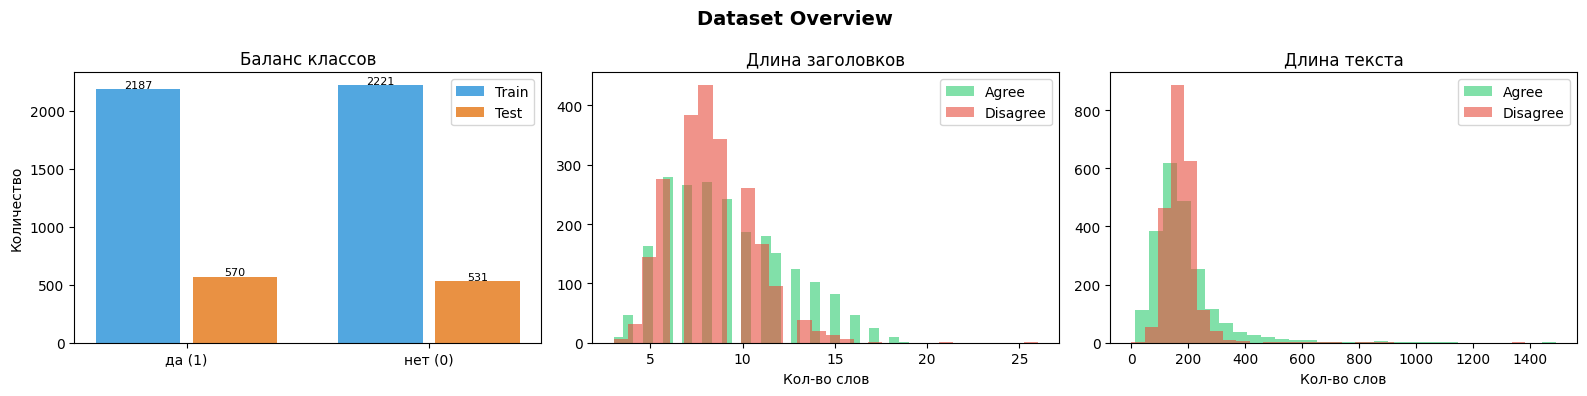

        hl_wc  body_wc
count  4408.0   4408.0
mean      8.8    181.3
std       2.8    101.1
min       3.0      1.0
25%       7.0    131.0
50%       8.0    166.0
75%      10.0    204.0
max      26.0   1491.0


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')

# 1 график - баланс классов
labels_map = {1: 'agree', 0: 'disagree'}
train_counts = data_train['Stance'].map(labels_map).value_counts()
test_counts  = data_test['Stance'].map(labels_map).value_counts()
x = np.arange(2)
axes[0].bar(x - 0.2, [train_counts.get('agree',0), train_counts.get('disagree',0)],
            0.35, label='Train', color='#3498db', alpha=0.85)
axes[0].bar(x + 0.2, [test_counts.get('agree',0),  test_counts.get('disagree',0)],
            0.35, label='Test',  color='#e67e22', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['да (1)', 'нет (0)'])
axes[0].set_title('Баланс классов')
axes[0].set_ylabel('Количество')
axes[0].legend()
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 str(int(bar.get_height())), ha='center', fontsize=8)

# 2 — Распределение количества слов в заголовках (используя очищенный Headline) в тренировочном наборе
data_train['hl_wc']   = data_train['Headline'].str.split().str.len()
data_train['body_wc'] = data_train['articleBody'].str.split().str.len()
for lbl, color, name in [(1,'#2ecc71','Agree'),(0,'#e74c3c','Disagree')]:
    axes[1].hist(data_train[data_train['Stance']==lbl]['hl_wc'],
                 bins=30, alpha=0.6, color=color, label=name)
axes[1].set_title('Длина заголовков')
axes[1].set_xlabel('Кол-во слов')
axes[1].legend()

# 3 — длина текста новостей в тренировочном наборе
for lbl, color, name in [(1,'#2ecc71','Agree'),(0,'#e74c3c','Disagree')]:
    axes[2].hist(data_train[data_train['Stance']==lbl]['body_wc'],
                 bins=30, alpha=0.6, color=color, label=name)
axes[2].set_title('Длина текста')
axes[2].set_xlabel('Кол-во слов')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(data_train[['hl_wc','body_wc']].describe().round(1))

- классы сбалансированы как в тренировочном так и в тестовом наборе
- средняя длина заголовков в диапазоне 8-10 слов
- в среднем длина текстов составляет 100-300 слов, есть выбросы в районе 1500 слов

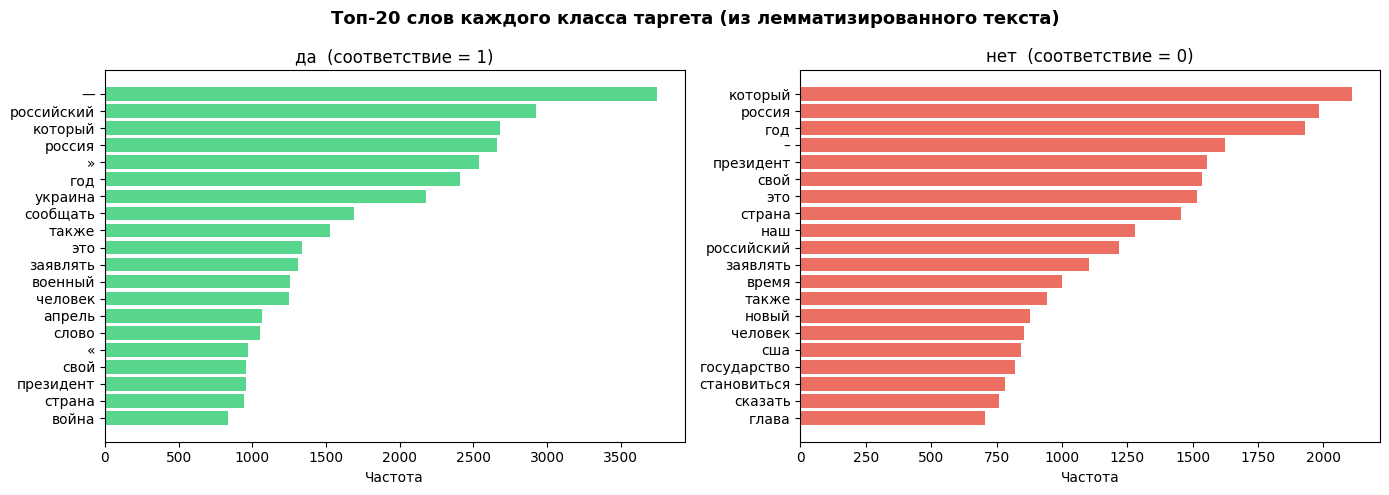

In [19]:
from collections import Counter

# Топ слов каждого класса по лемматизированному тексту в тренировочном наборе
def top_words(series, n=20):
    return Counter(' '.join(series.dropna()).split()).most_common(n)

agree_words = top_words(data_train[data_train['Stance']==1]['articleBody2'])
disagree_words = top_words(data_train[data_train['Stance']==0]['articleBody2'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Топ-20 слов каждого класса таргета (из лемматизированного текста)', fontsize=13, fontweight='bold')
for ax, words, color, title in [
    (axes[0], agree_words,    '#2ecc71', 'да  (соответствие = 1)'),
    (axes[1], disagree_words, '#e74c3c', 'нет  (соответствие = 0)')
]:
    lbls, cnts = zip(*words)
    ax.barh(lbls[::-1], cnts[::-1], color=color, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Частота')
plt.tight_layout()
plt.savefig('eda_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# сравнение 3 версий заголовков
print('сравнение 3 версий заголовков:')
print('=' * 80)
for _, row in data_train.head(3).iterrows():
    print(f"  Соответствие заголовка с содержимым текста : {'да' if row['Stance']==1 else 'нет'}")
    print(f"  Заголовок    : {row['Headline']}")
    print(f"  Заголовок 1   : {row['Headline1']}")
    print(f"  Заголовок 2   : {row['Headline2']}")
    print('-' * 80)

сравнение 3 версий заголовков:
  Соответствие заголовка с содержимым текста : да
  Заголовок    : российский бюджет марте недополучил 300 миллиардов рублей нефтегазовых доходов
  Заголовок 1   : российский бюджет в марте недополучил более 300 миллиардов рублей нефтегазовых доходов
  Заголовок 2   : российский бюджет март недополучать миллиард рубль нефтегазовый доход
--------------------------------------------------------------------------------
  Соответствие заголовка с содержимым текста : да
  Заголовок    : банк россии решил снизить ключевую ставку 20 17
  Заголовок 1   : банк россии решил снизить ключевую ставку с 20  до 17 
  Заголовок 2   : банк россия решать снижать ключевой ставка
--------------------------------------------------------------------------------
  Соответствие заголовка с содержимым текста : нет
  Заголовок    : мыс идокопас нато назвали первую цель начала полномасштабного вторжения россию
  Заголовок 1   : мыс идокопас  в нато назвали первую цель для начала по

## 4.Feature Engineering

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

y_train = data_train['Stance'].values   # 1=да, 0=нет
y_test  = data_test['Stance'].values

# Векторизация TF-IDF 
tfidf_hl_word   = TfidfVectorizer(ngram_range=(1,2), max_features=30000,
                                   sublinear_tf=True, min_df=2 #убираем редко встречающиеся слова
                                 )
tfidf_hl_char   = TfidfVectorizer(analyzer='char_wb', #символьные n-граммы внутри слов
                                  ngram_range=(3,5),
                                   max_features=20000, sublinear_tf=True, min_df=2)
tfidf_body_word = TfidfVectorizer(ngram_range=(1,2), max_features=60000,
                                   sublinear_tf=True, min_df=2)

# Fit на тренировочных, transform на тесте
HL_tr   = tfidf_hl_word.fit_transform(data_train['Headline2'])
HLC_tr  = tfidf_hl_char.fit_transform(data_train['Headline2'])
BODY_tr = tfidf_body_word.fit_transform(data_train['articleBody2'])

HL_te   = tfidf_hl_word.transform(data_test['Headline2'])
HLC_te  = tfidf_hl_char.transform(data_test['Headline2'])
BODY_te = tfidf_body_word.transform(data_test['articleBody2'])

print(f'Количество слов и символов в заголовках : {HL_tr.shape[1] + HLC_tr.shape[1]:,}')
print(f'Количество текста: {BODY_tr.shape[1]:,}')

Количество слов и символов в заголовках : 26,856
Количество текста: 60,000


In [22]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack, csr_matrix

#создаем признаки схожести между заголовком и текстом новости через cosine_similarity
# общий tf-idf
tfidf_shared = TfidfVectorizer(max_features=50000)
# объединение заголовков и текстов трейна в общий словарь 
tfidf_shared.fit(pd.concat([data_train['Headline2'], data_train['articleBody2']]))

#пребразование в векторы
HL_tr_s = tfidf_shared.transform(data_train['Headline2'])
BODY_tr_s = tfidf_shared.transform(data_train['articleBody2'])

HL_te_s = tfidf_shared.transform(data_test['Headline2'])
BODY_te_s = tfidf_shared.transform(data_test['articleBody2'])

#создаем матрицу схожести заголовка и текста п
cos_tr = cosine_similarity(HL_tr_s, BODY_tr_s).diagonal().reshape(-1,1)
cos_te = cosine_similarity(HL_te_s, BODY_te_s).diagonal().reshape(-1,1)

#Объединяем признаки:TF-IDF слов заголовка+TF-IDF символов+ TF-IDF текста+cos_tr 1 дополнительный признак
X_train = hstack([HL_tr, HLC_tr, BODY_tr, csr_matrix(cos_tr)])
X_test  = hstack([HL_te, HLC_te, BODY_te, csr_matrix(cos_te)])
print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')

X_train : (4408, 86857)
X_test  : (1101, 86857)


## 5. Построение моделей

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score, roc_curve)

# Правдивость: класс 1=да, 0=нет 
#4 модели обучения
classifiers = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'LinearSVC':           LinearSVC(C=0.5, max_iter=3000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                                       random_state=42),
}

tfidf_results = {}

for name, clf in classifiers.items():
    t0 = time.time()
    clf.fit(X_train, y_train)
    preds   = clf.predict(X_test)
    elapsed = time.time() - t0
#метрики качества
    report = classification_report(y_test, preds,
                                    target_names=['disagree(0)','agree(1)'],
                                    output_dict=True)
    try:
        prob = clf.predict_proba(X_test)[:,1]   # вероятность класса 1
        auc  = roc_auc_score(y_test, prob)
    except AttributeError:
        prob, auc = None, None
        
#метрики качества
    tfidf_results[name] = dict(
        accuracy=report['accuracy'],
        f1_agree=report['agree(1)']['f1-score'],
        f1_disagree=report['disagree(0)']['f1-score'],
        f1_macro=report['macro avg']['f1-score'],
        auc=auc, time_s=elapsed, preds=preds, proba=prob
    )
    print(f'\n{"="*55}\n  {name}  ({elapsed:.1f}s)\n{"="*55}')
    print(classification_report(y_test, preds, target_names=['disagree(0)','agree(1)']))
    if auc: print(f'  ROC-AUC: {auc:.4f}')


  Logistic Regression  (0.5s)
              precision    recall  f1-score   support

 disagree(0)       0.92      0.92      0.92       531
    agree(1)       0.93      0.93      0.93       570

    accuracy                           0.92      1101
   macro avg       0.92      0.92      0.92      1101
weighted avg       0.92      0.92      0.92      1101

  ROC-AUC: 0.9800

  LinearSVC  (0.2s)
              precision    recall  f1-score   support

 disagree(0)       0.94      0.95      0.95       531
    agree(1)       0.95      0.95      0.95       570

    accuracy                           0.95      1101
   macro avg       0.95      0.95      0.95      1101
weighted avg       0.95      0.95      0.95      1101


  Random Forest  (10.3s)
              precision    recall  f1-score   support

 disagree(0)       0.89      0.95      0.92       531
    agree(1)       0.95      0.89      0.92       570

    accuracy                           0.92      1101
   macro avg       0.92      0.9

## 6. Оценка результатов

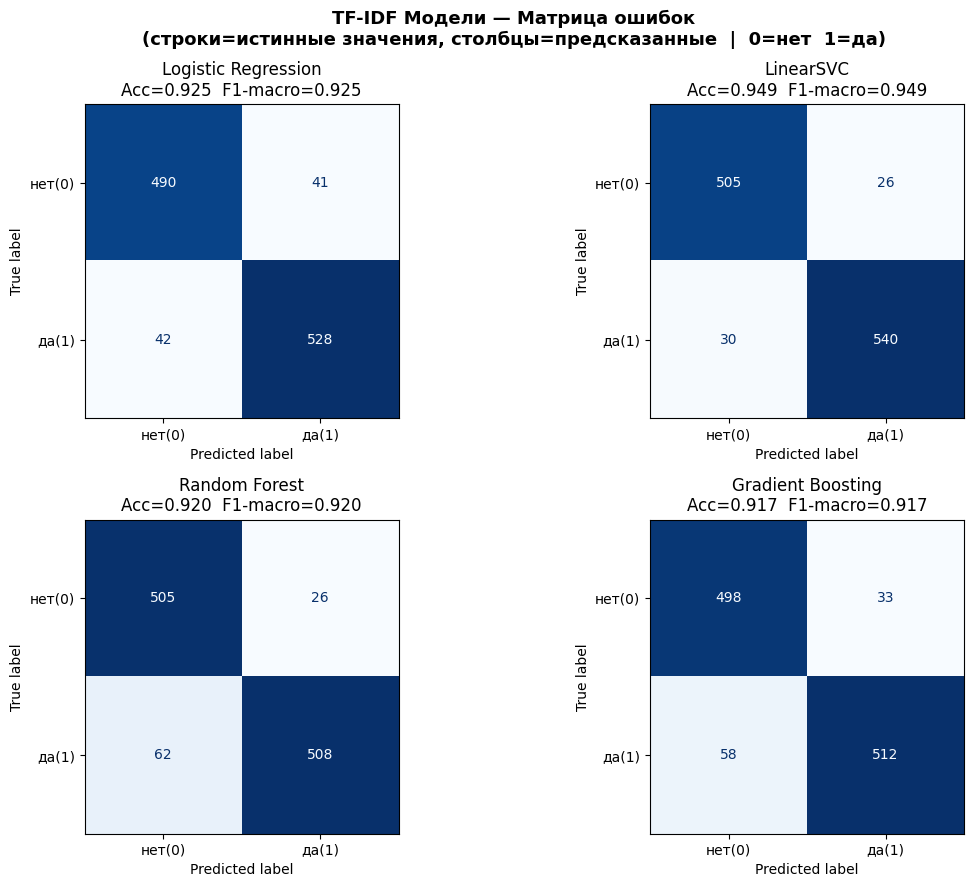

In [24]:
#Визуализация результатов
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('TF-IDF Модели — Матрица ошибок\n(строки=истинные значения, столбцы=предсказанные  |  0=нет  1=да)',
             fontsize=13, fontweight='bold')

for ax, (name, res) in zip(axes.flatten(), tfidf_results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    ConfusionMatrixDisplay(cm, display_labels=['нет(0)','да(1)']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{name}\nAcc={res['accuracy']:.3f}  F1-macro={res['f1_macro']:.3f}")

plt.tight_layout()
plt.savefig('tfidf_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

- Лучшая модель: LinearSVC
- FP (ложно "да") = 26
- FN (пропущенные "да") = 30

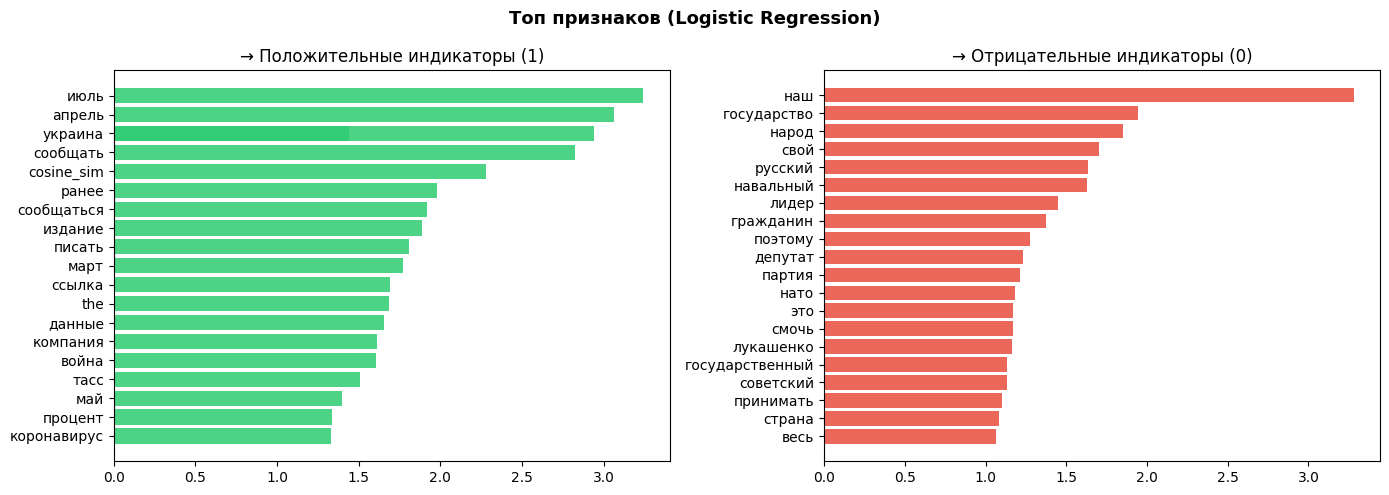

In [25]:
# Топ описываемых признаков — Logistic Regression
lr = classifiers['Logistic Regression']
feature_names = np.array(
    tfidf_hl_word.get_feature_names_out().tolist() +
    tfidf_hl_char.get_feature_names_out().tolist() +
    tfidf_body_word.get_feature_names_out().tolist() +
    ['cosine_sim','word_overlap','jaccard','hl_len','body_len']
)
coefs = lr.coef_[0]
top_agree    = np.argsort(coefs)[-20:][::-1]   # выше коэффициент - предсказание соответсвия заголовка и текста(1)
top_disagree = np.argsort(coefs)[:20]           # ниже коэффициент  - предсказание несоответсвия заголовка и текста(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Топ признаков (Logistic Regression)', fontsize=13, fontweight='bold')
axes[0].barh(feature_names[top_agree],    coefs[top_agree],             color='#2ecc71', alpha=0.85)
axes[0].set_title('→ Положительные индикаторы (1)'); axes[0].invert_yaxis()
axes[1].barh(feature_names[top_disagree], np.abs(coefs[top_disagree]),  color='#e74c3c', alpha=0.85)
axes[1].set_title('→ Отрицательные индикаторы (0)'); axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig('tfidf_features.png', dpi=150, bbox_inches='tight')
plt.show()

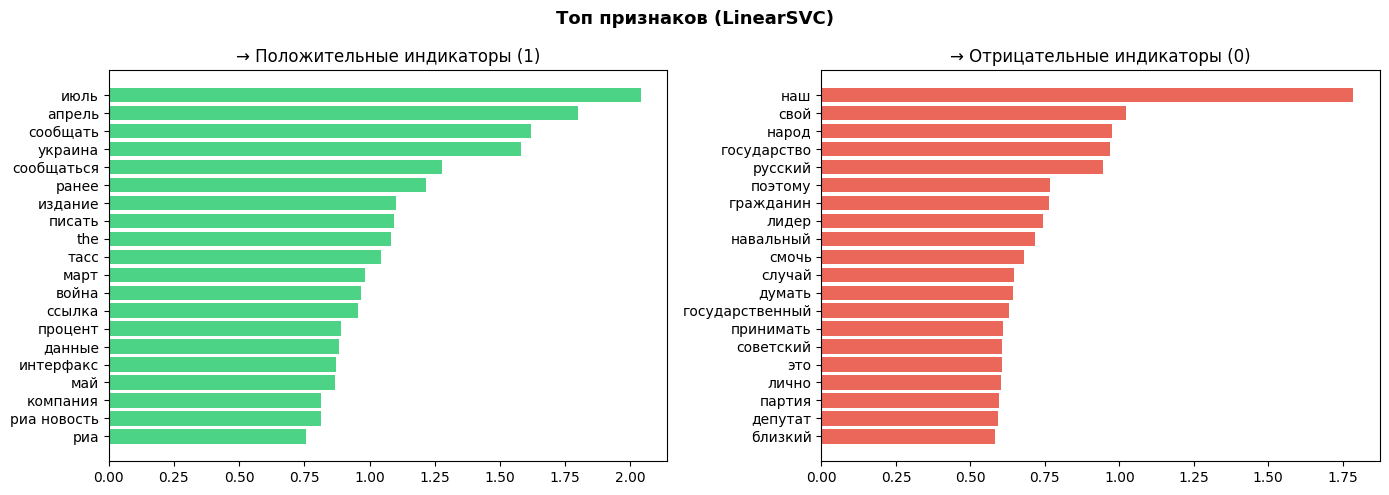

In [26]:
# Топ описываемых признаков — LinearSVC

svc = classifiers['LinearSVC']

feature_names = np.array(
    tfidf_hl_word.get_feature_names_out().tolist() +
    tfidf_hl_char.get_feature_names_out().tolist() +
    tfidf_body_word.get_feature_names_out().tolist() +
    ['cosine_sim','word_overlap','jaccard','hl_len','body_len']
)

coefs = svc.coef_[0]

top_agree    = np.argsort(coefs)[-20:][::-1]   # → класс 1
top_disagree = np.argsort(coefs)[:20]          # → класс 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Топ признаков (LinearSVC)', fontsize=13, fontweight='bold')

axes[0].barh(feature_names[top_agree], coefs[top_agree],
             color='#2ecc71', alpha=0.85)
axes[0].set_title('→ Положительные индикаторы (1)')
axes[0].invert_yaxis()

axes[1].barh(feature_names[top_disagree], np.abs(coefs[top_disagree]),
             color='#e74c3c', alpha=0.85)
axes[1].set_title('→ Отрицательные индикаторы (0)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('tfidf_features_svc.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Сохранение моделей и построение приложения на Streamlit

In [27]:
import joblib

joblib.dump(tfidf_hl_word, 'tfidf_hl_word.pkl')
joblib.dump(tfidf_hl_char, 'tfidf_hl_char.pkl')
joblib.dump(tfidf_body_word, 'tfidf_body_word.pkl')
joblib.dump(tfidf_shared, 'tfidf_shared.pkl')
joblib.dump(classifiers['LinearSVC'], 'svc_stance.pkl')
print(' модели сохранены')

 модели сохранены


In [28]:
import streamlit, pandas,numpy, sklearn, scipy, joblib

print(f"streamlit:  {streamlit.__version__}")
print(f"pandas:     {pandas.__version__}")
print(f"numpy:     {numpy.__version__}")
print(f"sklearn:    {sklearn.__version__}")
print(f"scipy:    {scipy.__version__}")
print(f"joblib:     {joblib.__version__}")

streamlit:  1.55.0
pandas:     2.3.3
numpy:     2.3.3
sklearn:    1.6.1
scipy:    1.17.0
joblib:     1.5.3


In [29]:
%%writefile requirements.txt 
streamlit==1.55.0
pandas==2.3.3
numpy==2.3.3
scikit-learn==1.6.1
scipy==1.17.0
joblib==1.5.3

Writing requirements.txt


In [30]:
%%writefile stance_detection_app.py
import streamlit as st
import joblib
import numpy as np
from scipy.sparse import hstack
from sklearn.metrics.pairwise import cosine_similarity

# Заголовок
st.title("❓ Классификатор правдивости новости")

# Загрузка моделей
tfidf_hl_word = joblib.load('tfidf_hl_word.pkl')
tfidf_hl_char = joblib.load('tfidf_hl_char.pkl')
tfidf_body_word = joblib.load('tfidf_body_word.pkl')
tfidf_shared = joblib.load('tfidf_shared.pkl')

model = joblib.load('svc_stance.pkl')




# Ввод пользователя
headline = st.text_input("📝 Введите заголовок")
body = st.text_area("📘 Введите текст статьи")

# Кнопка
if st.button("🔍 Проверить"):
    if headline and body:
        # TF-IDF
        hl_w = tfidf_hl_word.transform([headline])
        hl_c = tfidf_hl_char.transform([headline])
        hl_s = tfidf_shared.transform([headline])

        
        body_v = tfidf_body_word.transform([body])
        body_s = tfidf_shared.transform([body])



        #  cosine функция
        cos = cosine_similarity(hl_s, body_s)[0][0]
        cos = np.array([[cos]])

        # Объединение
        X = hstack([hl_w, hl_c, body_v, cos])

        # Предсказание
        pred = model.predict(X)[0]

        if pred == 1:
            st.success("✅ Заголовок согласуется с текстом (Правда)")
        else:
            st.error("❌ Заголовок НЕ соответствует тексту (Фейк)")
    else:
        st.warning("Введите и заголовок, и текст")

st.caption("🏦 Определитель правдивости новостных статей  |  LinearSVC with TF-IDF | Курс ML, Итоговый проект Каренкиной Сабины | ")

Writing stance_detection_app.py
